In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q tensorflow opencv-python matplotlib scikit-learn

In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
dataset_path = "/content/drive/MyDrive/Faceproject/Dataset/Colab_Data/Training"

print(os.listdir(dataset_path))

['real_part', 'fake_part']


In [ ]:
processed_path = "/content/processed_dataset"

folders = [
    "train/real",
    "train/fake",
    "val/real",
    "val/fake",
    "test/real",
    "test/fake"
]

for folder in folders:
    os.makedirs(os.path.join(processed_path, folder), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [ ]:
for class_name in ["real_part", "fake_part"]:

    class_path = os.path.join(dataset_path, class_name)

    label = "real" if class_name == "real_part" else "fake"

    destination = os.path.join(processed_path, "train", label)

    for root, dirs, files in os.walk(class_path):

        if os.path.basename(root).lower() == "color":

            for file in files:

                if file.lower().endswith((".jpg", ".jpeg", ".png")):

                    src = os.path.join(root, file)

                    dst = os.path.join(
                        destination,
                        f"{label}_{len(os.listdir(destination)):06d}.jpg"
                    )

                    shutil.copy2(src, dst)

print("Color images copied successfully!")

Color images copied successfully!


In [ ]:
random.seed(42)

for label in ["real", "fake"]:

    train_folder = f"/content/processed_dataset/train/{label}"
    val_folder   = f"/content/processed_dataset/val/{label}"
    test_folder  = f"/content/processed_dataset/test/{label}"

    images = os.listdir(train_folder)
    random.shuffle(images)

    n = len(images)

    val_count = int(0.15 * n)
    test_count = int(0.15 * n)

    val_images = images[:val_count]
    test_images = images[val_count:val_count+test_count]

    for img in val_images:
        shutil.move(
            os.path.join(train_folder, img),
            os.path.join(val_folder, img)
        )

    for img in test_images:
        shutil.move(
            os.path.join(train_folder, img),
            os.path.join(test_folder, img)
        )

print("Train / Validation / Test split completed!")

Train / Validation / Test split completed!


In [ ]:
print("Train Real :", len(os.listdir("/content/processed_dataset/train/real")))
print("Train Fake :", len(os.listdir("/content/processed_dataset/train/fake")))

print("Val Real   :", len(os.listdir("/content/processed_dataset/val/real")))
print("Val Fake   :", len(os.listdir("/content/processed_dataset/val/fake")))

print("Test Real  :", len(os.listdir("/content/processed_dataset/test/real")))
print("Test Fake  :", len(os.listdir("/content/processed_dataset/test/fake")))

Train Real : 2711
Train Fake : 5456
Val Real   : 580
Val Fake   : 1168
Test Real  : 580
Test Fake  : 1168


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_gen.flow_from_directory(
    "/content/processed_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = test_gen.flow_from_directory(
    "/content/processed_dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    "/content/processed_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 8167 images belonging to 2 classes.
Found 1748 images belonging to 2 classes.
Found 1748 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 150s 516ms/step - accuracy: 0.6490 - loss: 0.6395 - val_accuracy: 0.8490 - val_loss: 0.3786
Epoch 2/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 98s 383ms/step - accuracy: 0.8832 - loss: 0.3194 - val_accuracy: 0.9428 - val_loss: 0.2212
Epoch 3/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 101s 392ms/step - accuracy: 0.9469 - loss: 0.2033 - val_accuracy: 0.9720 - val_loss: 0.1497
Epoch 4/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 98s 384ms/step - accuracy: 0.9699 - loss: 0.1427 - val_accuracy: 0.9805 - val_loss: 0.1121
Epoch 5/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 99s 387ms/step - accuracy: 0.9804 - loss: 0.1111 - val_accuracy: 0.9851 - val_loss: 0.0898


In [ ]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)

55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9834 - loss: 0.0894
Test Accuracy: 0.983409583568573


In [ ]:
pred = model.predict(test_data)
pred_labels = (pred > 0.5).astype(int)

print(
    classification_report(
        test_data.classes,
        pred_labels
    )
)

55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1168
           1       1.00      0.95      0.97       580

    accuracy                           0.98      1748
   macro avg       0.99      0.97      0.98      1748
weighted avg       0.98      0.98      0.98      1748



In [ ]:
os.makedirs(
    "/content/drive/MyDrive/Faceproject/models",
    exist_ok=True
)

model.save(
    "/content/drive/MyDrive/Faceproject/models/liveness_model.h5"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/Faceproject/outputs",
    exist_ok=True
)

print("Outputs folder ready!")

Outputs folder ready!


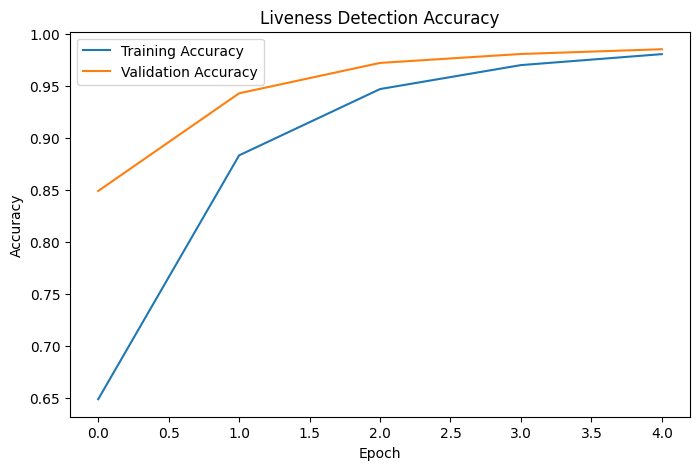

Saved: /content/drive/MyDrive/Faceproject/outputs/accuracy_plot.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Liveness Detection Accuracy')
plt.legend()

save_path = "/content/drive/MyDrive/Faceproject/outputs/accuracy_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", save_path)

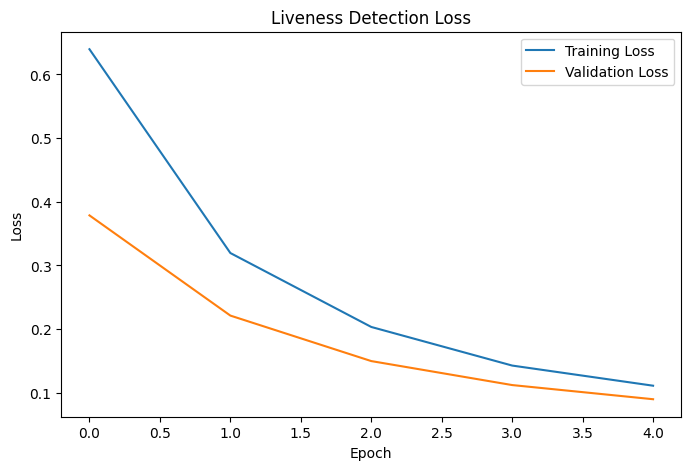

Saved: /content/drive/MyDrive/Faceproject/outputs/loss_plot.png


In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Liveness Detection Loss')
plt.legend()

save_path = "/content/drive/MyDrive/Faceproject/outputs/loss_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", save_path)

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step


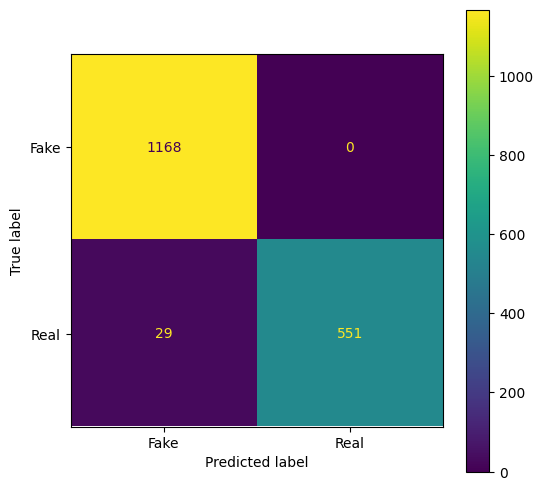

Saved: /content/drive/MyDrive/Faceproject/outputs/confusion_matrix.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = model.predict(test_data)
pred_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(
    test_data.classes,
    pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax)

save_path = "/content/drive/MyDrive/Faceproject/outputs/confusion_matrix.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", save_path)

In [ ]:
import pickle

with open(
    "/content/drive/MyDrive/Faceproject/models/training_history.pkl",
    "wb"
) as f:
    pickle.dump(history.history, f)

print("Training history saved.")

Training history saved.


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Pick one random test image
img_path = "/content/processed_dataset/test/real/" + os.listdir("/content/processed_dataset/test/real")[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0][0]

print("Image:", img_path)

if pred > 0.5:
    print("Prediction: REAL FACE")
    print("Confidence:", round(pred*100,2), "%")
else:
    print("Prediction: FAKE FACE")
    print("Confidence:", round((1-pred)*100,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
Image: /content/processed_dataset/test/real/real_001391.jpg
Prediction: REAL FACE
Confidence: 94.15 %


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "/content/drive/MyDrive/Faceproject/models/liveness_model.h5"
)

print("Model loaded successfully!")

Model loaded successfully!
